# 🧪 Exercise 6 and 7:

This notebook explores core probability and probability distributions concepts using the CICIDS2017 dataset. We will treat the network monitoring process as an experiment and define various events, compute probabilities, conditional probabilities, and use Bayes' Theorem to evaluate risk.

The file Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv is one of the labeled flow-level traffic logs from the CICIDS2017 dataset. It was generated by the Canadian Institute for Cybersecurity as part of their Intrusion Detection System (IDS) benchmarking project. Here's a structured description of the dataset:

🔢 Size: 225,745 rows × 79 columns (≈77.12 MB)
📅 Scenario Date: Friday Afternoon
📌 Attack Type Simulated: DDoS (Distributed Denial of Service)
🧪 Data Source: CICFlowMeter from raw PCAPs

Each row represents a single network flow — that is, a unidirectional sequence of packets between two IP/Port pairs over a transport-layer protocol within a timeout window.

| Category                 | Examples (Columns)                                                     | Description                                     |
| ------------------------ | ---------------------------------------------------------------------- | ----------------------------------------------- |
| 🧭 Flow Identifiers      | `Destination Port`, `Flow Duration`, `Label`                           | Flow metadata and attack labeling               |
| 📦 Packet Statistics     | `Total Fwd Packets`, `Total Backward Packets`, `Fwd Packet Length Max` | Counts and lengths of packets in each direction |
| ⏱ Inter-arrival Times    | `Flow IAT Mean`, `Fwd IAT Total`, `Bwd IAT Max`                        | Time between packets (IAT = Inter-Arrival Time) |
| 🚩 TCP Flags             | `SYN Flag Count`, `ACK Flag Count`, `FIN Flag Count`                   | Transport-level signal flags                    |
| 📈 Flow Rates            | `Flow Bytes/s`, `Flow Packets/s`, `Fwd Packets/s`                      | Throughput and packet rate                      |
| 🧮 Header/Segment Stats  | `Fwd Header Length`, `Avg Fwd Segment Size`, `Init_Win_bytes_forward`  | TCP/IP header info                              |
| 🧪 Statistical Features  | `Packet Length Mean`, `Packet Length Std`, `Idle Mean`, `Active Min`   | Derived statistics of activity and idle periods |
| 🏷 Labels (Ground Truth) | `Label`                                                                | BENIGN or DDoS attack flow                      |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
# Load dataset
file_path = "./Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
df = pd.read_csv(file_path)

In [3]:
# Show a sample
print("Sample data:")
df.head()

Sample data:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [9]:
# Quick clean-up of column names
df.columns = df.columns.str.strip()

<Axes: >

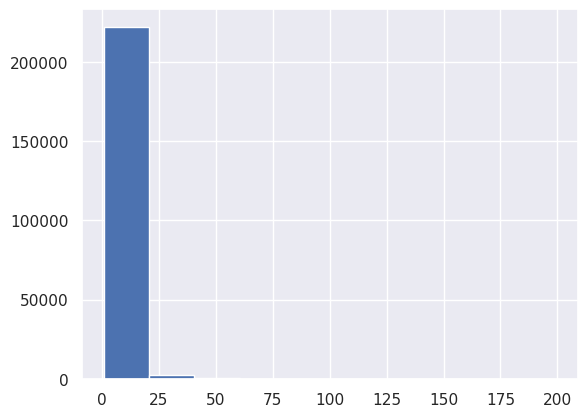

In [10]:
df[df["Total Fwd Packets"] <200]["Total Fwd Packets"].hist()

### Section 1 (probability):
#### ✅ Task for students:
Briefly define what an experiment and event mean in this network monitoring context.

In [5]:
Your_Answer = (
    "An experiment is observing a single network flow (a row in the dataset). "
    "An event is a specific outcome, e.g., 'flow is an attack' or 'port = 80' or Flow Duration exceeds 1 second...etc"
)

**NOTE:**
- Experiment = observe one flow
- Event = something true about that flow

In this dataset, the experiment is observing a network flow, while an event is a specific condition or outcome of that observation, such as the flow being a DDoS attack.

#### ✅ Task for students:
What is sample space? what is the size of main events?

In [8]:
# Sample Space and Events
sample_space_size = len(df)

num_attacks = df[df['Label'] != 'BENIGN'].shape[0]

num_benigns = df[df['Label'] == 'BENIGN'].shape[0]

print(f"Sample size: {sample_space_size}")

print(f"Possible Events are attacks: {num_attacks} and Benign {num_benigns}")

Sample size: 225745
Possible Events are attacks: 128027 and Benign 97718


**NOTE:**
- *.shape* gives (rows, columns)
- *.shape[0]* = number of rows

#### ✅ Task for students:
Estimate the probability of attack and the probability of getting a benign traffic upon a check|

In [13]:
p_attack = num_attacks / sample_space_size
p_benign = num_benigns / sample_space_size

print(f"P(attack) = {p_attack:.4f}")
print(f"P(benign) = {p_benign:.4f}")

P(attack) = 0.5671
P(benign) = 0.4329


#### ✅ Task for students:
Based on the sample estimate conditional Probability P(Attack | Destination Port = 80)

In [20]:
# P(Attack | Destination Port = 80)
num_of_flows_on_port_80 = df[df['Destination Port'] == 80]
num_of_attacks_on_port_80 = num_of_flows_on_port_80[num_of_flows_on_port_80['Label'] != 'BENIGN']

print(f"P(Attack | Destination Port = 80): {len(num_of_attacks_on_port_80)/len(num_of_flows_on_port_80):.4f}")

P(Attack | Destination Port = 80): 0.9348


#### ✅ Task for students:
Calculate P(Destination Port = 80 | Attack)

In [22]:
# Using the dataframe
# all attack flows
attack_flows = df[df['Label'] != 'BENIGN']

# attack flows on destination port 80
attack_port_80 = attack_flows[attack_flows['Destination Port'] == 80]

# conditional probability
p_port80_given_attack = len(attack_port_80) / len(attack_flows)

print(f"P(Destination Port = 80 | Attack): {p_port80_given_attack}")

P(Destination Port = 80 | Attack): 0.999976567442805


In [23]:
# Using Bayes’ Theorem
joint_count_attack_and_port80 = df[(df['Label'] != 'BENIGN') & (df['Destination Port'] == 80)].shape[0]
p_attack_and_port80 = joint_count_attack_and_port80/ len(df)

p_port80_given_Attack = p_attack_and_port80 / p_attack


print(f"Using Bayes' Theorem: P(Port 80 | attack) = {p_port80_given_Attack:.5f}")

Using Bayes' Theorem: P(Port 80 | attack) = 0.99998


**NOTE:** Bayes lets you say:

“I know how common attacks are overall,
and how often attack & port 80 happen together,
so I can compute how likely port 80 is given an attack.”

#### 👉 Conclusion: 
If a flow is headed to port 80, there’s a ~93.5% chance it’s an attack in this dataset — very high because this file contains mostly DDoS traffic aimed at port 80.

#### ✅ Task for students:
Choose 'Flow Duration'>1,000,000 μs and formulate a Bayes theorem-based question. i.e. compute P(Attack∣Long Duration) 

In [25]:
# Define long duration threshold (in microseconds)
duration_threshold = 1_000_000

# P(Long Duration)
p_long_duration = (df['Flow Duration'] > duration_threshold).mean()

# P(Long Duration | Attack)
attacks = df[df['Label'] != 'BENIGN']
p_long_duration_given_attack = (attacks['Flow Duration'] > duration_threshold).mean()

# Apply Bayes' Theorem
p_attack_given_long_duration = (p_long_duration_given_attack * p_attack) / p_long_duration if p_long_duration else 0

print(f"P(Long Duration)={p_long_duration}")
print(f"P(Long Duration | Attack)= {p_long_duration_given_attack}")
print(f"P(Attack | Long Duration)= {p_attack_given_long_duration}")

P(Long Duration)=0.5570045848191544
P(Long Duration | Attack)= 0.6613995485327314
P(Attack | Long Duration)= 0.6734239428666863


**NOTE:**
- *.mean()* = count / total

**Bayes = “AND divided by GIVEN”**

$$
P(A \mid B) = \frac{P(A \cap B)}{P(B)}
$$

#### 👉 Conclusion:
If you observe a long-duration flow, there is a ~67% chance that it is an attack — higher than the base rate of 56.7%.

### Section 2 (bionomial distribution):
#### ✅ Task for students:
- Suppose you want to simulate attack or benign events out of 10 random flows.
-  can we assume this is a bionomial experiment and why?
- Estimate the attack rate p from the dataset and model it as a binomial distribution to find probability of getting exactly 7 attacks in our simulation?
- When can we use a normal distribution to approximate such a binomial experiment?

**NOTE:**
A binomial distribution describes:

How many times an event happens when you repeat the same yes/no experiment many times.

The 4 conditions (must remember)

A situation is binomial if:

- 1️⃣ Fixed number of trials (n)
- 2️⃣ Each trial has two outcomes (yes/no)
- 3️⃣ Probability of “yes” (p) is the same every time
- 4️⃣ Trials are independent

Very simple example (coin)

- Flip a coin 10 times
- Success = “Heads”
- Question: How many heads will you get?

👉 That count follows a binomial distribution.

In [27]:
from scipy import stats

attack_prob = (df['Label'] != 'BENIGN').mean()
print(f"Estimated attack probability (p): {attack_prob:.4f}")

n_trials = 10
k_success = 7

# pmf = probability mass function
binom_prob = stats.binom.pmf(k_success, n_trials, attack_prob) # note: to get the documentation, you may need to print help(stats.binom); the parent class
print(f"P(getting exactly 7 attacks out of 10) = {binom_prob:.4f}")

Estimated attack probability (p): 0.5671
P(getting exactly 7 attacks out of 10) = 0.1837


👉 **Can we assume this is a binomial experiment and why?**

✔ Yes, we can model it as a binomial experiment.

**Why?** Because it satisfies all the binomial conditions:

* There are a fixed number of trials (n = 10 flows).
* Each trial has only two possible outcomes: "Attack" or "Benign".
* The probability of attack (p) is assumed constant across trials.
* Trials are independent (assuming random sampling).

So this is a classic binomial setup.

---

👉  When can we use a normal distribution to approximate such a binomial experiment?

We can use the **normal approximation to the binomial** when:

$$
n \cdot p \geq 10 \quad \text{and} \quad n \cdot (1-p) \geq 10
$$

✅ In this case, if you increase n (say, to 100), and both np and n(1-p) are ≥ 10, then the binomial distribution becomes approximately normal:

$$
X \sim \mathcal{N}(\mu = np, , \sigma = \sqrt{np(1-p)})
$$

This makes calculations easier for large simulations.

**NOTE:** When we try something many times and get lots of yeses and noes, the results look smooth, so we can use a normal distribution instead of counting exactly.

- Few tries → count exactly (binomial)
- Many tries → smooth curve (normal)

#### Explanations of the above normal distribution
#### **Imagine a dart game 🌟**
You and your friend throw darts at a target.

- **You** hit: 8, 9, 10, 9, 9 (all close to center)
- **Your friend** hits: 2, 15, 5, 18, 10 (all over the place)

Both have the **same average** (mean) of 9 points, but your friend’s scores are **spread out** more.

**Variance** and **standard deviation** are just **math tools** to measure "how spread out" the results are.

---

#### **1. Variance**
**Variance** = the *average* of the *squared distances* from the mean.

#### Step-by-step for coin flips:
Let’s take **1 coin flip**, heads = 1, tails = 0, p = 0.5.

**Mean (average)** = \( p = 0.5 \).

Distance from mean for:
- Heads (1): \( 1 - 0.5 = 0.5 \) → square it → \( 0.25 \)
- Tails (0): \( 0 - 0.5 = -0.5 \) → square it → \( 0.25 \)

Each happens half the time, so:
\[
\text{Variance} = (0.25 \times 0.5) + (0.25 \times 0.5) = 0.125 + 0.125 = 0.25
\]

**Shortcut formula**: Variance = \( p(1-p) = 0.5 \times 0.5 = 0.25 \).

**For n flips**: variance = \( n \times p \times (1-p) \).

Example: 100 flips, p=0.5 →  
Variance = \( 100 \times 0.5 \times 0.5 = 25 \).

But notice: variance = 25 what? **“Squared heads”** — that’s weird to think about.

---

#### **2. Standard deviation**
We want “spread” in **same units** as “number of heads” (not “heads squared”).  
So we take the **square root of variance**.

Standard deviation = √variance

For 1 flip: √0.25 = 0.5 heads  
For 100 flips: √25 = 5 heads

---

#### **What does standard deviation = 5 heads mean?**
If you flip 100 fair coins many times:
- On average you get 50 heads.
- But most of the time (about 68% of experiments), you’ll get **between 45 and 55 heads** (that’s 50 ± 5).
- Almost always (about 95% of experiments), between **40 and 60 heads** (50 ± 10, i.e., ± 2 standard deviations).

---

#### **Visual idea**
**Small standard deviation** = all results bunched near average.  
**Large standard deviation** = results are scattered far from average.

---

**Simple summary:**  
- **Variance** = measure of spread in "squared units" (math convenience).
- **Standard deviation** = square root of variance → spread in "normal units" (easy to understand: typical distance from average).
- For coin flips:  
  **Variance** = \( n \times p \times (1-p) \)  
  **Standard deviation** = \( \sqrt{n \times p \times (1-p)} \)

### Section 3 (normal distribution):
#### ✅ Task for students:
- Choose a numerical feature 'Total Fwd Packets' and fit a normal distribution using MLE (Maximum Likelihood Estimation) using scipy stats model.
- Plot the histogram and overlay the fitted normal PDF. Does it match well?
- Does the normal curve align well with the histogram?
- Compare visually – are the tails and center well captured?
- Why might the fit not be perfect for real-world network data?
- Explain the shape of the data to your AI assistant and ask it to find a more suited distribution that can be used for the modeling.

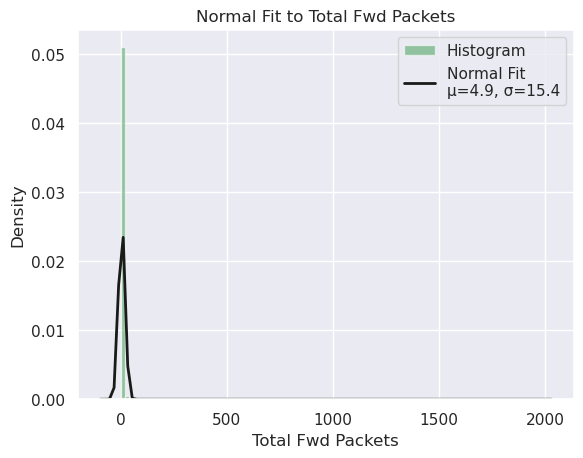

In [30]:
feature = 'Total Fwd Packets'

# Convert to numeric, coerce errors (e.g. "Infinity" → NaN), drop NaNs and infs
data = pd.to_numeric(df[feature], errors='coerce')
data = data[np.isfinite(data)]  # remove NaN, inf, -inf


# Fit a normal distribution to the data using MLE (more general than just mean/std)
mu, std = stats.norm.fit(data)

# Plot histogram and PDF
plt.hist(data, bins=100, density=True, alpha=0.6, color='g', label='Histogram')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f"Normal Fit\nμ={mu:.1f}, σ={std:.1f}")
plt.title(f"Normal Fit to {feature}")
plt.xlabel(feature)
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

👉 Does the normal curve align well with the histogram?

❌ Not perfectly.
While the fitted normal curve may roughly align with the center of the histogram, it often misses the shape of the tails and over- or underestimates the peak. The mismatch is especially noticeable in skewed or heavy-tailed data.

---
👉   Are the tails and center well captured?

* ✅ The center (peak) may be partially captured, especially if the data is unimodal.
* ❌ The tails are often poorly modeled — normal distributions assume symmetric, light tails, while real data often has skewness or extreme values.
* In the histogram, we see longer right tails or sharper peaks that the normal curve smooths out.

---

👉  Why might the fit not be perfect for real-world network data?

Because network traffic features (like flow size, duration, packet rate) tend to be:

* 📈 Right-skewed (due to large rare flows)
* ⚠️ Heavy-tailed (some flows are orders of magnitude larger)
* 🔄 Multi-modal (due to different protocols or traffic types)

These properties violate the assumptions of normality (symmetry and light tails), so the normal distribution can only offer a rough approximation — not a perfect model.

---

👉   Explain the shape of the data to your AI assistant and ask it to find a more suited distribution that can be used for the modeling:

The log-normal distribution is better choice to fit the skewed, heavy-tailed shape much better than the normal .

The normal fit underestimates the peak and overestimates the tails.

#### ✅ Task for students:
- Choose a numerical feature 'Flow Duration' and plot its distribution.
- Comment on the shape (normal, skewed, multimodal?)
- Compute the skewness and the kurtosis.

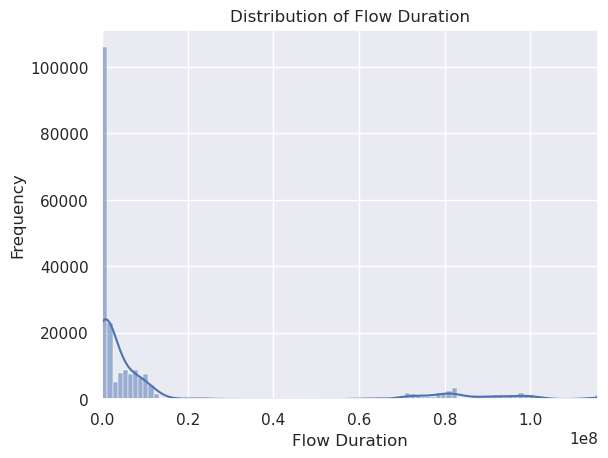

In [31]:
feature = 'Flow Duration'
sns.histplot(df[feature], bins=100, kde=True)
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Frequency")
plt.xlim(0, df[feature].quantile(0.99))
plt.show()

In [32]:
print(f"Skewness of {feature}: {df[feature].skew():.2f}")
print(f"Kurtosis of {feature}: {df[feature].kurtosis():.2f}")

Skewness of Flow Duration: 1.94
Kurtosis of Flow Duration: 2.12


#### Interpretation:
Flow Duration is highly right-skewed (positive skew).

Most flows are short, but some last a very long time (heavy tail).

Skewness > 0 → long tail to the right.

Kurtosis > 0 → more peaked and heavy-tailed than normal.

**Easy way to remember 🧠**
| Measure  | Question it answers          |
| -------- | ---------------------------- |
| Skewness | “Which side is longer?”      |
| Kurtosis | “How extreme are the tails?” |

**Simple example**

Packet counts:
>5, 6, 7, 8, 2000

- Extreme value far from center
- Heavy tail

👉 High kurtosis

### Section 4 (outliers):
#### ✅ Task for students:
Use IQR method to detect and count outliers in 'Flow Duration'.

Take a look on the Benign and Attack traffic when flow duration has an extreme value

In [33]:
Q1 = df[feature].quantile(0.25)
Q3 = df[feature].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]


print(f"Total outliers in {feature}: {len(outliers)}")
print("Outliers by label:")
print(outliers['Label'].value_counts())

Total outliers in Flow Duration: 37465
Outliers by label:
Label
DDoS      21915
BENIGN    15550
Name: count, dtype: int64


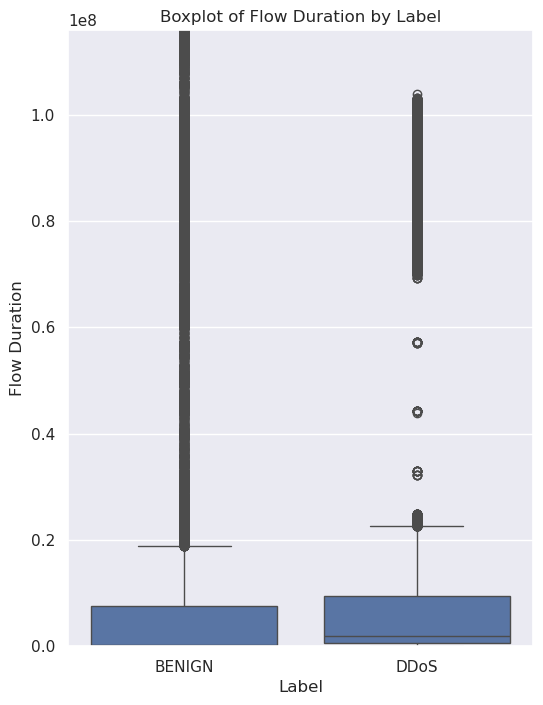

In [34]:
# Boxplot for visual confirmation
plt.figure(figsize=(6, 8))
sns.boxplot(x='Label', y=feature, data=df, showfliers=True)
plt.title("Boxplot of Flow Duration by Label")
plt.ylim(0, df[feature].quantile(0.99))
plt.show()

### Section 5 (CLT):
#### ✅ Task for students:
- In the following code, we sample different sample sizes and compute mean/std. 
- Do you expect the mean and the std. to change for each sample size? why do you think this is happening?
- What happens if you increase sample size?

In [35]:
sample_sizes = [10, 20, 50, 100, 250, 500, 750, 1000, 2000, 5000, 10000, 20000, 30000]
means = []
stds = []
column = 'Flow Bytes/s'

for size in sample_sizes:
    sample = df[column].dropna().sample(size, random_state=42)
    means.append(sample.mean())
    stds.append(sample.std())

In [36]:
df[column].dropna().mean()

np.float64(inf)

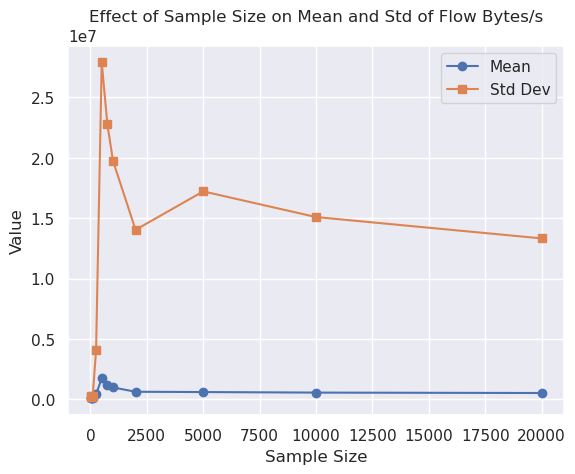

In [37]:
# Plot the trend
plt.plot(sample_sizes, means, marker='o', label='Mean')
plt.plot(sample_sizes, stds, marker='s', label='Std Dev')
plt.title("Effect of Sample Size on Mean and Std of Flow Bytes/s")
plt.xlabel("Sample Size")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

#### Interpretation:

✅ What you should observe:
As sample size increases:
- Mean stabilizes and fluctuates less.

- Standard deviation also stabilizes.

- Small samples are more sensitive to extreme values.

✅ Why it matters:

- Larger samples give more reliable estimates of the population mean and std.

- Statistical summaries from small samples may be misleading.

- This is foundational for statistical confidence and inference

**NOTE:**
The mean and standard deviation vary for small sample sizes due to random sampling variability. As the sample size increases, these estimates stabilize and converge to the true population values due to the law of large numbers.

🧠 How to answer similar questions (pattern)
- Small sample → unstable statistics
- Large sample → stable statistics
- Use law of large numbers

#### ✅ Task for students:
We will assume that our dataset represent a population. In the following code we take repeated samples (1000 repeats)from the population, first with sample size of 10, 50, 500 and 1000  and plot the distribution of sample means.

##### Answer the following questions in a dedicated markdown cell.

- How does the shape of the sampling distribution change as n increases?

- Why is the distribution for n = 10 much more variable and irregular than the one for n = 500?

- Which sample size looks closest to a normal distribution? Explain why.

- Compare the standard deviation of the sample means vs. the standard deviation of the variable, and confirm that std of sample means < std of population (by √n rule).

- Compare the distribution of Flow duration vs. the different distributions of different sample means

Mean of sample means: 16373831.52
Std of sample means: 9805770.83


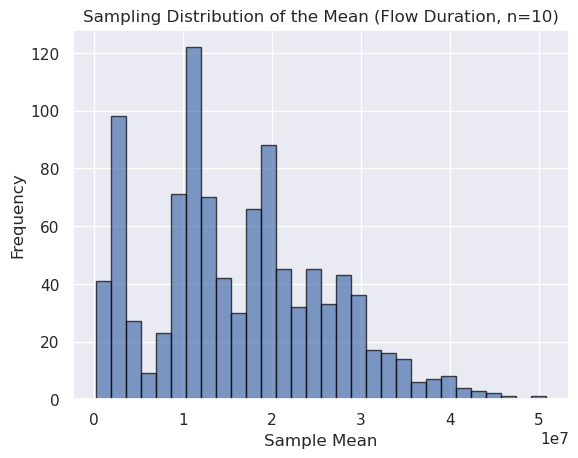

Mean of sample means: 16352609.97
Std of sample means: 4580272.42


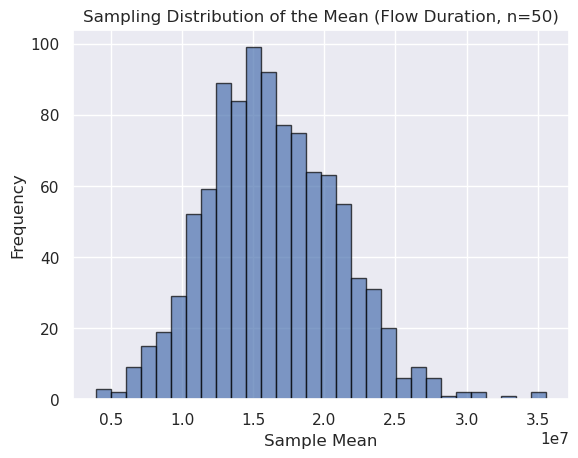

Mean of sample means: 16174019.99
Std of sample means: 1431979.84


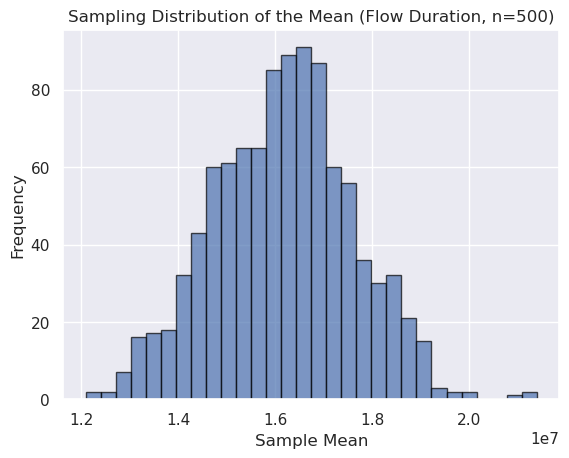

Mean of sample means: 16288068.23
Std of sample means: 1051363.89


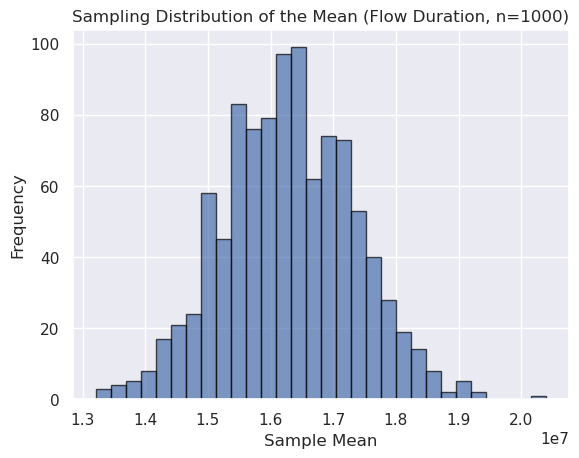

In [38]:

sample_sizes = [10, 50, 500, 1000]
column = 'Flow Duration'
data = df[column].dropna()

for sample_size in sample_sizes:
    sample_means = []
    for _ in range(1000):
        sample = data.sample(sample_size, replace=True)
        sample_means.append(sample.mean())

    print(f"Mean of sample means: {np.mean(sample_means):.2f}")
    print(f"Std of sample means: {np.std(sample_means):.2f}")
    
    plt.hist(sample_means, bins=30, edgecolor='black', alpha=0.7)
    plt.title(f"Sampling Distribution of the Mean (Flow Duration, n={sample_size})")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

#### Interpretation:
👉 What you should observe:

Even though Flow Duration is skewed, the distribution of sample means is approximately normal.

We can even assume that Mean of sample means ≈ population mean.

However, Std of sample means < std of population (by √n rule).

n = 10 → more variation, less bell-shaped

n = 500 → tightly clustered, nearly normal

👉 Why it matters:

The Central Limit Theory explains why many statistical procedures assume normality.

It enables confidence intervals and hypothesis tests even when the underlying data is not normal.

It's the backbone of inferential statistics.


👉 How does the shape of the sampling distribution change as n increases?

It becomes smoother, more symmetric, and closer to a normal (bell) curve.

---

👉 Why is the distribution for n = 10 more irregular than n = 500?

Smaller samples are more affected by randomness and outliers; larger samples average these out.

---

👉 Which sample size looks most normal? Why?

n = 500 — large samples make the mean distribution approximate normal due to the CLT.

---

👉 Compare std of sample means vs. population std

The std of sample means is smaller and follows:

$$
\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}
$$

---

👉 Compare Flow Duration vs. sample means distributions

Flow Duration is skewed and wide; sample means are more centered, symmetric, and narrower as n increases.

**NOTE:**
As sample size increases, the sampling distribution of the mean becomes more normal, narrower, and less variable. Small samples produce irregular and noisy distributions, while large samples produce stable, approximately normal distributions. The standard deviation of the sample mean is smaller than the population standard deviation and decreases according to the √n rule.

#### Explanation of the above scenario

#### Part 1: The story (no math yet)

#### Imagine this box 📦

Inside the box are **all flow durations** in your dataset.

That box = **population**

---

#### 1️⃣ Population

**Population** = *everything you care about*

👉 Here:

* All flow durations in the dataset
* This is the “truth”

**Population mean** = average of *all* flow durations
**Population std** = how spread out *all* flow durations are

---

#### 2️⃣ Sample

A **sample** = *you grab a few values from the box*

👉 Example:

* Pick **10** flow durations at random

That is **one sample**

---

#### 3️⃣ Sample mean

Now you compute:

> “What is the average of these 10 values?”

That number is called a **sample mean**

⚠️ Important:

* Different samples → different sample means

---

#### 4️⃣ Sample means (plural)

Now repeat:

* Take another 10 values
* Compute another mean
* Do this many times

You now have **many sample means**

---

#### 5️⃣ Sampling distribution (THIS IS THE KEY)

👉 The **sampling distribution** is:

> The distribution of all those sample means

It is **NOT the original data**
It is **a distribution of averages**

---

#### Part 2: Why small vs large samples behave differently

#### Case A: Sample size = 10

* Each average uses only **10 values**
* One extreme value can **dominate the average**

Result:

* Sample means jump around a lot
* Distribution is wide and messy

---

#### Case B: Sample size = 500

* Each average uses **500 values**
* Extreme values cancel out

Result:

* Sample means are close together
* Distribution is narrow and smooth

---

#### Part 3: Why it becomes normal (bell-shaped)

This is the **Central Limit Theorem (CLT)**, in plain words:

> When you average many random values, the averages tend to form a bell curve.

Even if:

* Original data is skewed
* Original data is messy

That’s why:

* n = 500 or 1000 → bell shape
* n = 10 → not yet

---

#### Part 4: Standard deviation — population vs sample mean

#### Population std (σ)

* Spread of **raw data**
* Usually large (Flow Duration is very spread out)

---

#### Std of sample means (σₓ̄)

* Spread of the **averages**
* Much smaller

Why?

> Averages are more stable than raw values

---

#### The √n rule (intuitive, no math)

If you average:

* 4 values → variability halves
* 100 values → variability becomes very small

Rule:
$$
\text{Std of sample mean} = \frac{\text{Population std}}{\sqrt{n}}
$$

---

#### Part 5: Compare raw data vs sampling distributions

| Thing                | Shape             | Spread      |
| -------------------- | ----------------- | ----------- |
| Flow Duration        | Skewed, messy     | Very wide   |
| Sample means (n=10)  | Somewhat smoother | Narrower    |
| Sample means (n=500) | Bell-shaped       | Very narrow |

---

#### Part 6: How to answer ANY exam question (template)

#### Question: *What happens when n increases?*

Answer:

> The sampling distribution becomes more normal and less variable.

---

#### Question: *Why is n=10 irregular?*

Answer:

> Small samples are strongly affected by randomness and extreme values.

---

#### Question: *Why std of sample mean < population std?*

Answer:

> Averaging reduces variability, and the reduction follows the √n rule.

---

#### Part 7: One mental picture (VERY IMPORTANT)

### Think of noise 🎧

* One measurement = very noisy
* Average of many measurements = smooth signal

👉 Sample mean = noise reduction

---

#### Final: One paragraph you can always write in exams

> A population contains all observations, while a sample is a subset. Each sample has its own mean, and repeating the sampling process produces a sampling distribution of the mean. As sample size increases, the sampling distribution becomes more normal and less variable due to the Central Limit Theorem. The standard deviation of the sample mean is smaller than that of the population and decreases with √n.

---

#### 🧠 10-second memory rule (write this on your brain)

**Raw data → messy**
**Means → smooth**
**Bigger sample → tighter bell**

#### ✅ Task for students:

overlay the sampling distribution of means (when n=50) with normal distribution

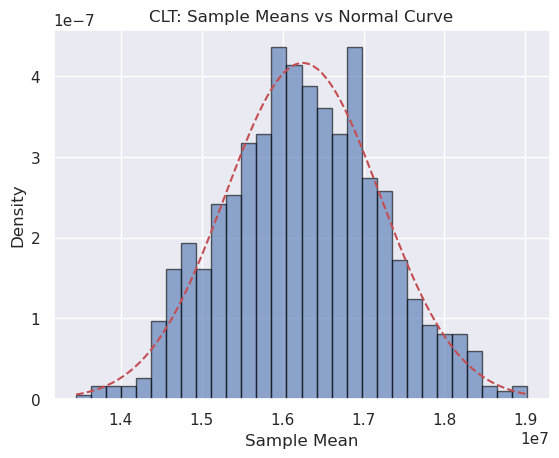

In [39]:
# ✅ Task for students:
# overlay the sampling distribution of means (when n=50) with normal distribution

sample_means = []
sample_sizes = 50
column = 'Flow Duration'
data = df[column].dropna()

for _ in range(1000):
    sample = data.sample(sample_size, replace=True)
    sample_means.append(sample.mean())

        

from scipy.stats import norm


mu = np.mean(sample_means)
sigma = np.std(sample_means)
x_vals = np.linspace(min(sample_means), max(sample_means), 100)
plt.hist(sample_means, bins=30, density=True, alpha=0.6, edgecolor='black')
plt.plot(x_vals, norm.pdf(x_vals, mu, sigma), 'r--')
plt.title("CLT: Sample Means vs Normal Curve")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.show()

#### What is **μ (mu)**?

👉 **μ means “average”**

* It is the **center** of the data
* Tells you where most values are around

#### Example

Flow durations:
`10, 20, 30`

μ = (10 + 20 + 30) / 3 = **20**

👉 In your code:

```python
mu = np.mean(sample_means)
```

μ = **average of all sample averages**

---

#### What is **σ (sigma)**?

👉 **σ means “spread”**

* Tells you **how far values usually are from the average**
* Bigger σ = more spread out
* Smaller σ = tightly clustered

#### Example

Values:

* 19, 20, 21 → small σ
* 5, 20, 100 → large σ

👉 In your code:

```python
sigma = np.std(sample_means)
```

σ = **how spread out the sample means are**

---

#### Visual intuition 🧠

* **μ** = center of the bell curve
* **σ** = width of the bell curve

```
        |
     ___|___   ← μ (center)
   /           \
  /             \
<---- σ ---->
```

---

#### One-line exam answer

> μ is the mean (average) of the distribution, and σ is the standard deviation, measuring how spread out the values are around the mean.

---

#### 3-second memory trick

**μ = middle**
**σ = spread**